In [24]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# sns.lineplot(
#     data={5: 1, 10: 2, 15: 6, 20: 8, 25: 15},
#     marker='o'
# )

# print(list(map(lambda x: x/10, range(0, 10, 1))))

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [25]:
sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.5)
sns.set_palette("Set1", 10)
sns.set_style({'font.family': 'serif', 'font.serif': 'Times New Roman'})

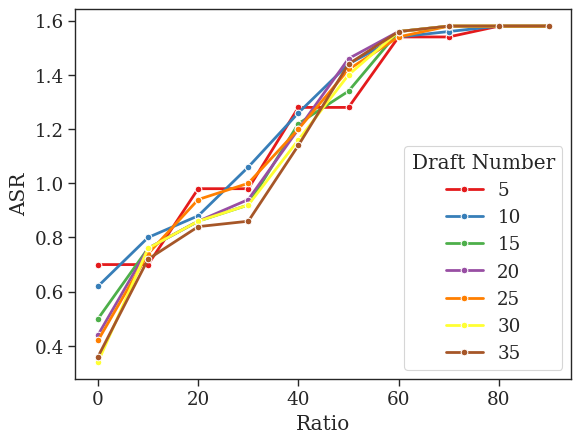

In [27]:
def construct_dataframe(
    dataset_name, target_model_name, generation_name, draft_model_name
):
    result = []
    for draft_number in range(5, 35 + 1, 5):
        for ratio in range(0, 100, 10):
            ratio_percentage = ratio / 100
            path = (
                Path.cwd().parent.parent
                / "workdir"
                / "step_7_result"
                / dataset_name
                / target_model_name
                / generation_name
                / draft_model_name
                / f"GPT_{ratio_percentage}.pkl"
            )
            df = pd.read_pickle(path)
            ASR = df.loc[f"sandbox_{draft_number}"]["ASR"]
            result.append(
                {
                    "Draft Number": draft_number,
                    "Ratio": ratio,
                    "ASR": ASR,
                }
            )
    df = pd.DataFrame(result)
    return df


def plot(dataset_name, target_model_name, generation_name, draft_model_name, x, hue):
    df = construct_dataframe(
        dataset_name, target_model_name, generation_name, draft_model_name
    )
    df["ASR_percentage"] = df["ASR"] * 100
    sns.lineplot(
        data=df,
        y="ASR_percentage",
        x=x,
        hue=hue,
        palette="Set1",
        marker="o",
        linewidth=2,
    )
    plt.xlabel(x)
    plt.ylabel("ASR")
    plt.show()


dataset_name = "RPAB"
target_model_name = "Meta-Llama-3-70B-Instruct-AWQ"
generation_name = "GCG"
draft_model_name = "opt-125m-AWQ"

plot(
    dataset_name,
    target_model_name,
    generation_name,
    draft_model_name,
    "Ratio",
    "Draft Number",
)

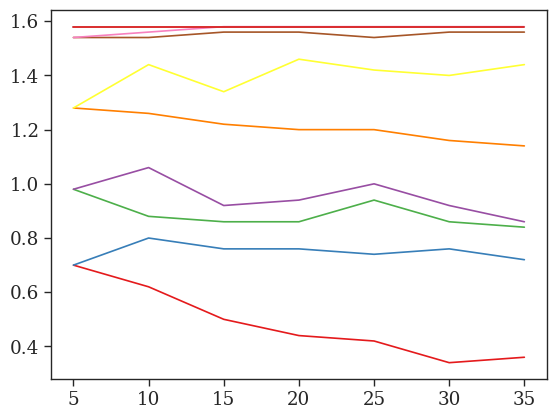

In [26]:
def plot_by_draft_number(dataset_name, target_model_name, generation_name, draft_model_name):
    for ratio in range(0, 100, 10):
        draft_number_list = range(5, 35 + 1, 5)
        y = []
        for draft_number in draft_number_list:
            ratio_percentage = ratio / 100
            path = f"../../workdir/step_7_result/{dataset_name}/{target_model_name}/{generation_name}/{draft_model_name}/GPT_{ratio_percentage}.pkl"
            df = pd.read_pickle(path)
            ASR = df.loc[f"sandbox_{draft_number}"]["ASR"]
            y.append(ASR)
        y = np.array(y) * 100
        plt.plot(draft_number_list, y, label=f"draft {draft_number}")


plot_by_draft_number("RPAB", "Meta-Llama-3-70B-Instruct-AWQ", "GCG", "opt-125m-AWQ")

c:\Users\htsai\src\proj-jailbreak-sandbox\src\core


C:\Users\htsai\AppData\Local\Temp\ipykernel_9920\543250427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df["ASR"]*100, fill=False, palette="Set1", ax=ax)
C:\Users\htsai\AppData\Local\Temp\ipykernel_9920\543250427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df["ASR"]*100, fill=False, palette="Set1", ax=ax)


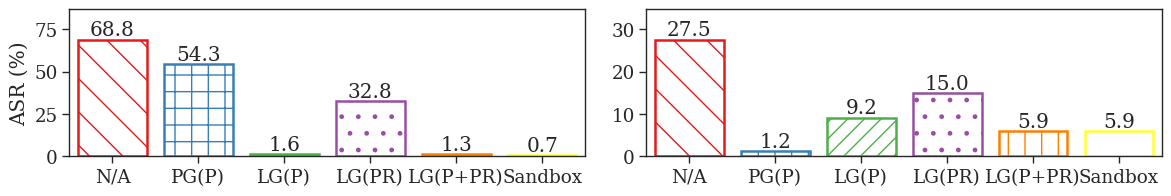

<Figure size 640x480 with 0 Axes>

In [8]:
# print current working directory
import os
print(os.getcwd())

def draw(df, ax):
    sns.barplot(df["ASR"]*100, fill=False, palette="Set1", ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', label_type='edge')

    # ax2 = plt.twinx()
    # sns.lineplot(data=df["average_time_for_successful_defense"], ax=ax2, marker="o")

    # ax.set_xticklabels(ax.get_xticklabels()) # rotation=45,ha="right",rotation_mode='anchor'
    ax.set_ylim(top=ax.get_ylim()[1] * 1.2)

    hatches = ['\\', '+', '//', '.', '|']
    for bars, hatch in zip(ax.containers, hatches):
        for bar in bars:
            bar.set_hatch(hatch)

fig, axes = plt.subplots(1, 2, figsize=(12, 2.2))

for i, generation_name in enumerate(['GCG', 'AutoDAN']):
    path = f"../../workdir/step_7_result/RPAB/Meta-Llama-3-70B-Instruct-AWQ/{generation_name}/opt-125m-AWQ/GPT_0.1.pkl"
    ax = axes[i]

    df = pd.read_pickle(path)

    df = df.loc[['NA', 'PromptGuard', 'LlamaGuardPrompt', 'LlamaGuardPromptResponse', 'LlamaGuardPrompt_and_LlamaGuardPromptResponse', 'sandbox_5']]
    df.index = ['N/A', 'PG(P)', 'LG(P)', 'LG(PR)', 'LG(P+PR)', 'Sandbox']

    draw(df, ax)

    if i == 0:
        ax.set(ylabel="ASR (%)")
    else:
        # hide y label
        ax.set(ylabel=None)

plt.tight_layout()

plt.savefig(r"C:\Users\htsai\src\2024-Defend-Transferable-Jailbreak-with-Speculative-Inference\figures\ASR_llama_bar.eps", bbox_inches='tight', transparent="True", pad_inches=0)

plt.show()

plt.clf()
# sns.lineplot(df["average_time_for_successful_defense"])

/tmp/ipykernel_92777/3681504195.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode='anchor')


[Text(0, 0, 'NA'),
 Text(1, 0, 'LlamaGuardPrompt'),
 Text(2, 0, 'LlamaGuardPromptResponse'),
 Text(3, 0, 'LlamaGuardPrompt_and_LlamaGuardPromptResponse'),
 Text(4, 0, 'sandbox_5'),
 Text(5, 0, 'sandbox_10'),
 Text(6, 0, 'sandbox_15'),
 Text(7, 0, 'sandbox_20'),
 Text(8, 0, 'sandbox_25'),
 Text(9, 0, 'sandbox_30'),
 Text(10, 0, 'sandbox_35')]

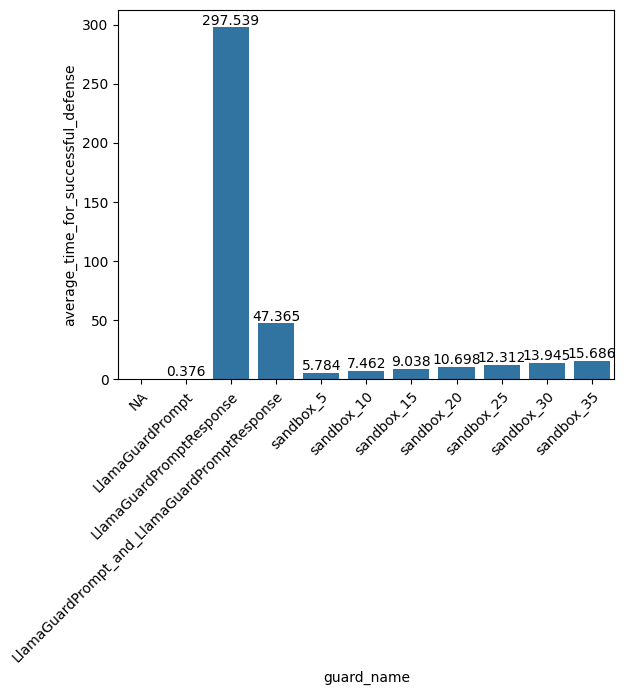

In [8]:
ax = sns.barplot(df["average_time_for_successful_defense"])
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge')

# ax2 = plt.twinx()
# sns.lineplot(data=df["average_time_for_successful_defense"], ax=ax2, marker="o")

ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode='anchor')